In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!apt-get install graphviz -y
!pip install pydot

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


使用原数据

In [ ]:
import pandas as pd
import numpy as np
import datetime
# 读取数据
features = pd.read_csv("/content/drive/MyDrive/529/train_data.csv")
# 假设 features 已经读取了数据
# 将 startdate 转换为 datetime 类型
# 尝试先统一格式
def fix_date_format(x):
    try:
        # 如果是 YYYY/MM/DD 格式
        if x.count('/') == 2 and len(x.split('/')[0]) == 4:
            dt = pd.to_datetime(x, format='%Y/%m/%d')
        else:
            dt = pd.to_datetime(x, format='%m/%d/%y')
        return dt
    except:
        return pd.NaT

features['startdate'] = features['startdate'].apply(fix_date_format)
# 拆分为日、月、年三个新列
features['day'] = features['startdate'].dt.day
features['month'] = features['startdate'].dt.month
features['year'] = features['startdate'].dt.year
#丢掉startdate为了排除掉TimeStamp
features = features.drop(['startdate', 'index'], axis=1)
#features = features.drop(['startdate'], axis=1)
# 查看结果
print(features[['day', 'month', 'year']].head(5))

   day  month  year
0    1      9  2014
1    2      9  2014
2    3      9  2014
3    4      9  2014
4    5      9  2014


In [ ]:
# 处理缺失值
from sklearn.impute import SimpleImputer
# 数值列：用中位数填充
num_cols = features.select_dtypes(include=['int64','float64']).columns
imputer_num = SimpleImputer(strategy='median')
features[num_cols] = imputer_num.fit_transform(features[num_cols])

# 类别列：用众数填充（最常见值）
cat_cols = features.select_dtypes(include=['object']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
features[cat_cols] = imputer_cat.fit_transform(features[cat_cols])

In [ ]:
print('数据维度：',features.shape)

数据维度： (375734, 247)


In [ ]:
features.describe()

,lat,lon,contest-pevpr-sfc-gauss-14d__pevpr,nmme0-tmp2m-34w__cancm30,nmme0-tmp2m-34w__cancm40,nmme0-tmp2m-34w__ccsm30,nmme0-tmp2m-34w__ccsm40,nmme0-tmp2m-34w__cfsv20,nmme0-tmp2m-34w__gfdlflora0,nmme0-tmp2m-34w__gfdlflorb0,...,wind-vwnd-925-2010-14,wind-vwnd-925-2010-15,wind-vwnd-925-2010-16,wind-vwnd-925-2010-17,wind-vwnd-925-2010-18,wind-vwnd-925-2010-19,wind-vwnd-925-2010-20,day,month,year
count,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,...,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000,375734.000000
mean,0.592766,0.517964,276.744064,10.801682,12.726739,10.073483,11.638229,10.733886,11.772646,11.694567,...,19.251970,-17.697565,-9.846867,-6.231860,16.014364,10.489945,11.296334,15.738714,6.519836,2015.166895
std,0.251744,0.272059,198.085182,10.952417,11.073553,10.118756,10.574276,9.403434,10.689967,10.681607,...,25.288526,31.946748,34.164678,27.050356,25.847455,25.070435,25.113214,8.803932,3.449555,0.687627
min,0.000000,0.000000,-2.310000,-14.960000,-14.970000,-11.720000,-17.560000,-13.720000,-13.330000,-13.520000,...,-39.280000,-100.560000,-106.080000,-93.980000,-52.610000,-66.110000,-57.610000,1.000000,1.000000,2014.000000
25%,0.409091,0.300000,104.062500,1.550000,3.650000,1.970000,3.080000,3.390000,2.970000,2.910000,...,1.960000,-40.030000,-32.170000,-20.170000,-0.360000,-6.790000,-5.570000,8.000000,4.000000,2015.000000
50%,0.590909,0.533333,250.320000,9.950000,11.890000,9.490000,11.600000,10.890000,11.280000,11.240000,...,20.050000,-16.710000,-8.560000,-6.030000,18.650000,11.860000,11.650000,16.000000,7.000000,2015.000000
75%,0.818182,0.766667,420.010000,20.230000,22.110000,18.360000,20.360000,18.330000,20.300000,20.160000,...,35.090000,4.390000,10.500000,11.630000,31.210000,29.040000,29.180000,23.000000,10.000000,2016.000000
max,1.000000,1.000000,1185.140000,36.080000,36.030000,33.390000,34.640000,35.750000,38.350000,38.450000,...,91.760000,56.550000,83.890000,64.850000,90.390000,76.890000,88.660000,31.000000,12.000000,2016.000000


In [ ]:
years = features['year']
months = features['month']
days = features['day']

#datetime格式
dates = [str(int(year)) + '-' + str(int(month)) + '-' + str(int(day)) for year,month,day in zip(years,months,days)]
dates = [datetime.datetime.strptime(date,'%Y-%m-%d') for date in dates]

In [ ]:
dates[:5]

[datetime.datetime(2014, 9, 1, 0, 0),
 datetime.datetime(2014, 9, 2, 0, 0),
 datetime.datetime(2014, 9, 3, 0, 0),
 datetime.datetime(2014, 9, 4, 0, 0),
 datetime.datetime(2014, 9, 5, 0, 0)]

In [ ]:
# 画图
import matplotlib.pyplot as plt

%matplotlib inline

# 默认风格
plt.style.use('fivethirtyeight')

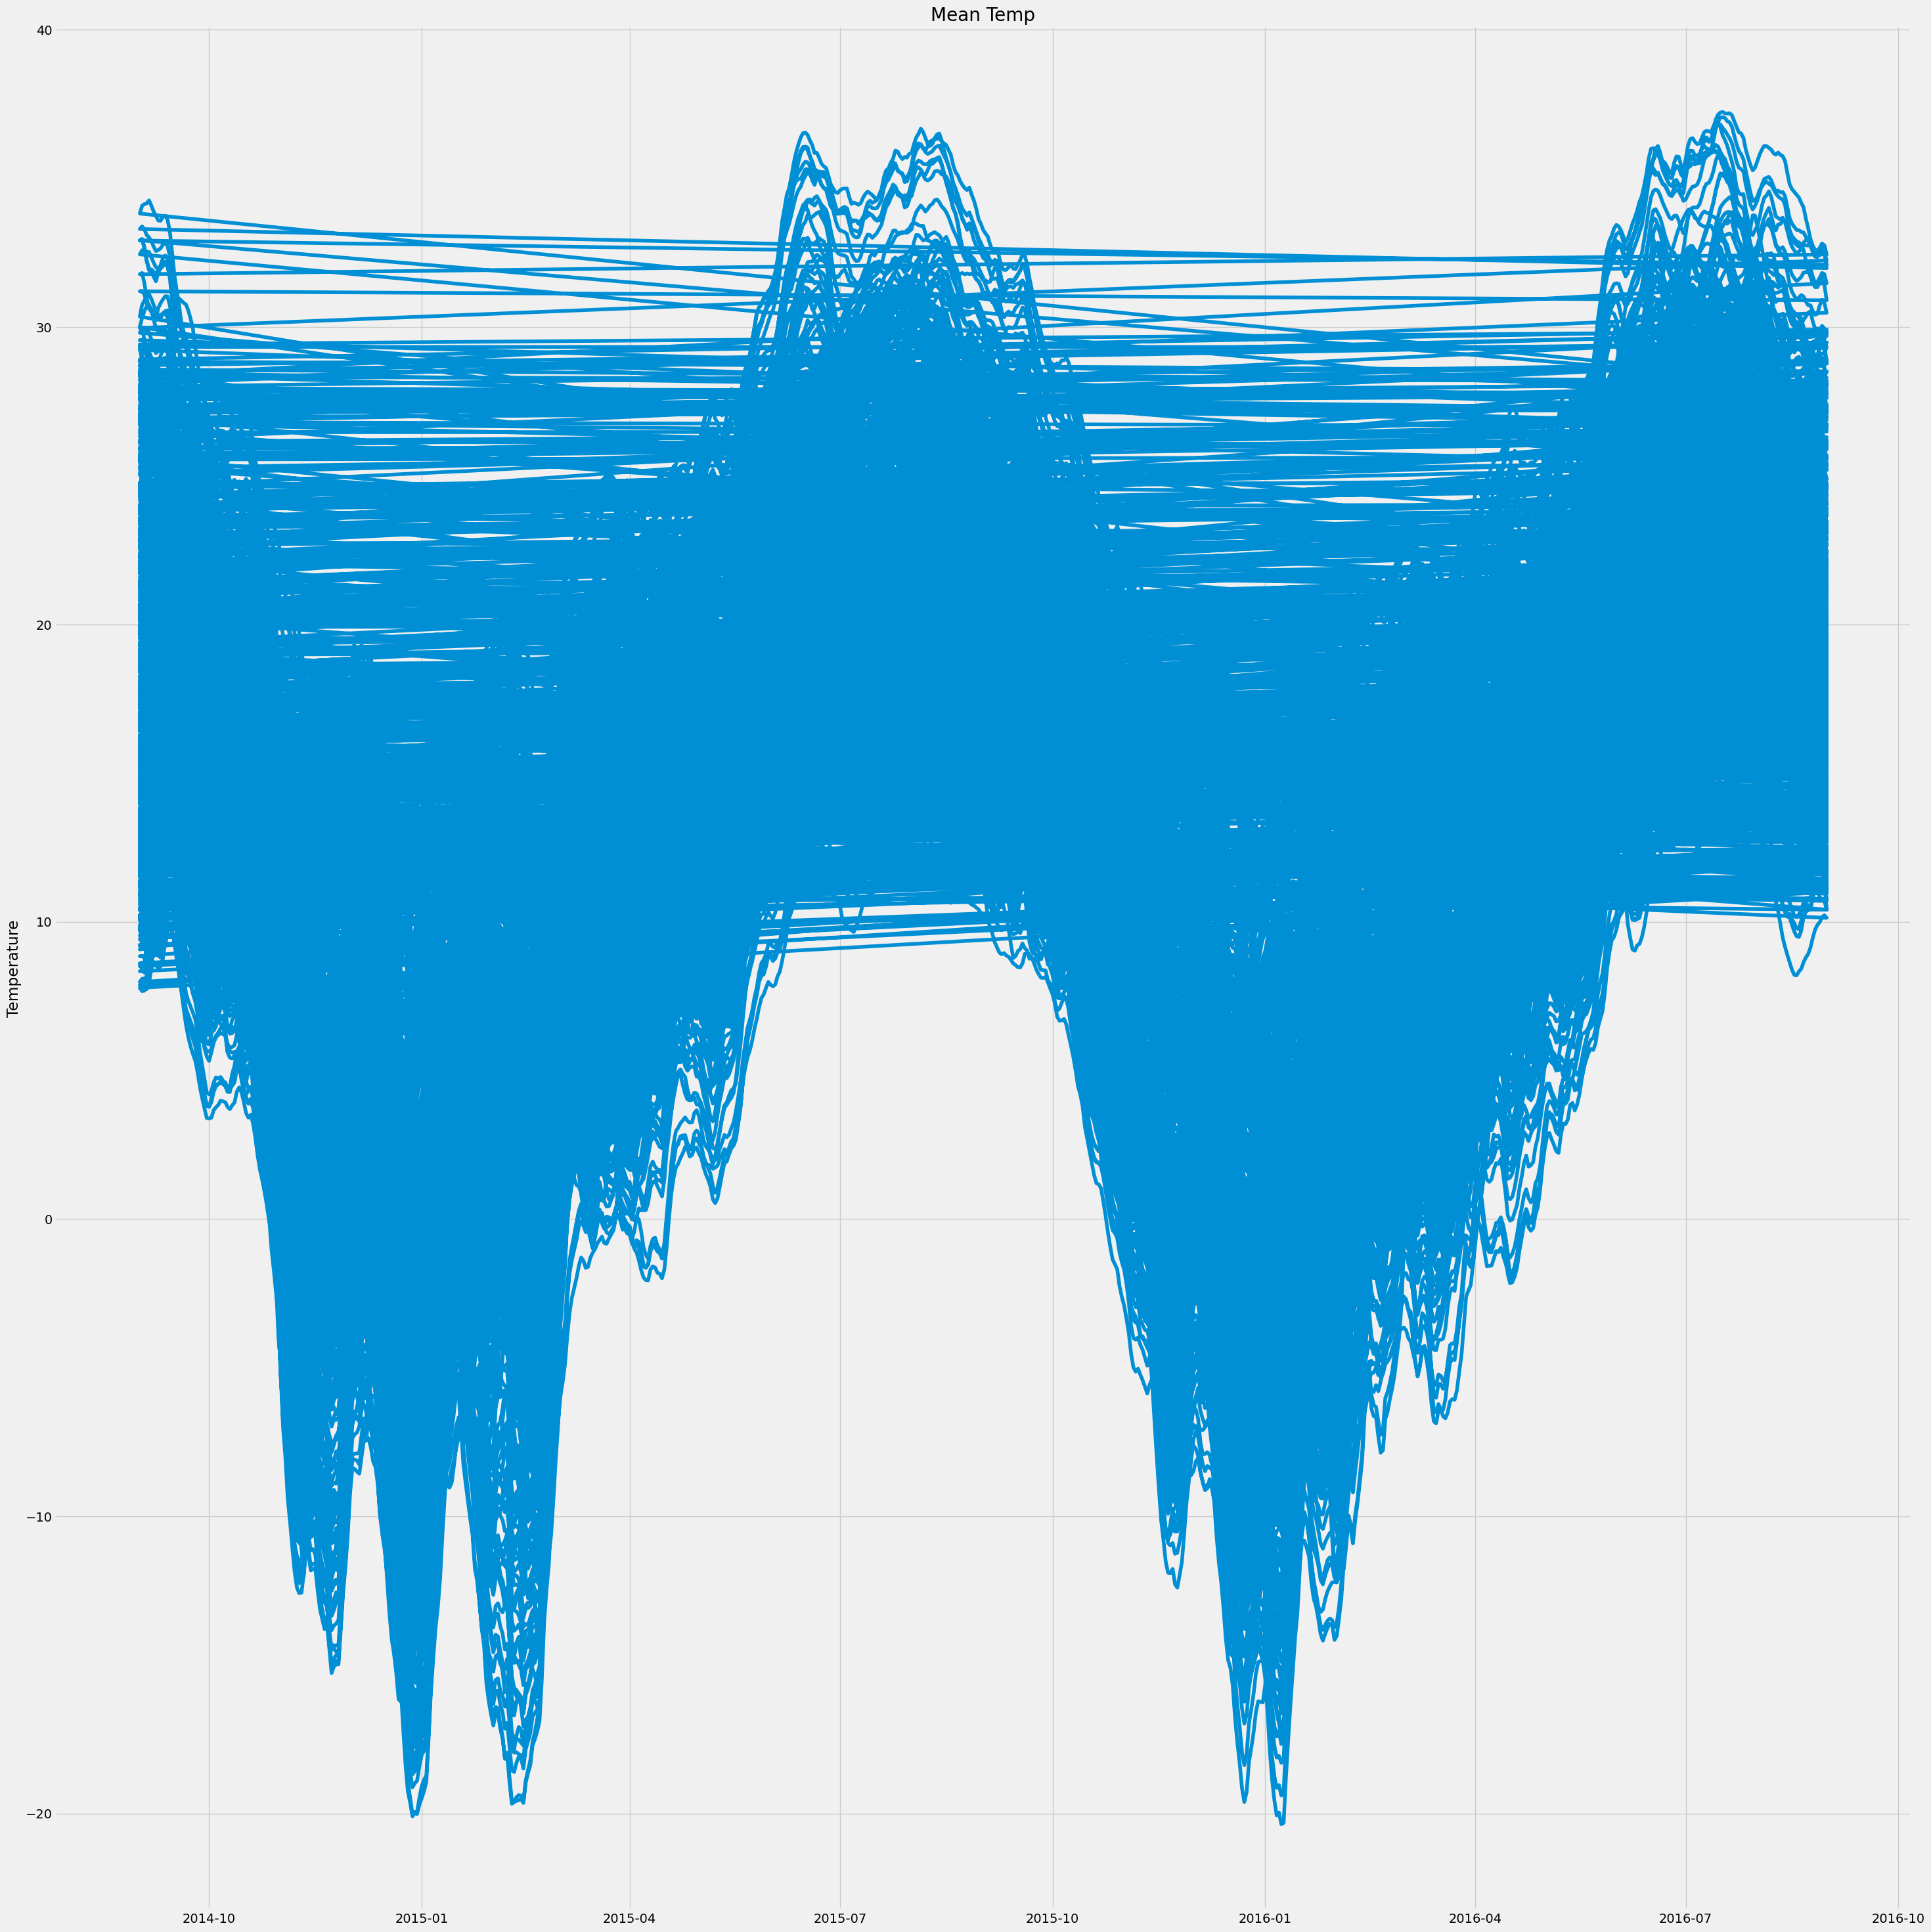

In [ ]:
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(30, 30))
# 标签值
ax1.plot(dates, features['contest-tmp2m-14d__tmp2m'])
ax1.set_xlabel('')
ax1.set_ylabel('Temperature')
ax1.set_title('Mean Temp')
plt.tight_layout(pad=2)
plt.show()

In [ ]:
#独热编码
features = pd.get_dummies(features,dtype = int)
features.head(5)

,lat,lon,contest-pevpr-sfc-gauss-14d__pevpr,nmme0-tmp2m-34w__cancm30,nmme0-tmp2m-34w__cancm40,nmme0-tmp2m-34w__ccsm30,nmme0-tmp2m-34w__ccsm40,nmme0-tmp2m-34w__cfsv20,nmme0-tmp2m-34w__gfdlflora0,nmme0-tmp2m-34w__gfdlflorb0,...,climateregions__climateregion_Cfb,climateregions__climateregion_Csa,climateregions__climateregion_Csb,climateregions__climateregion_Dfa,climateregions__climateregion_Dfb,climateregions__climateregion_Dfc,climateregions__climateregion_Dsb,climateregions__climateregion_Dsc,climateregions__climateregion_Dwa,climateregions__climateregion_Dwb
0,0.0,0.833333,237.00,29.02,31.64,29.57,30.73,29.71,31.52,31.68,...,0,0,0,0,0,0,0,0,0,0
1,0.0,0.833333,228.90,29.02,31.64,29.57,30.73,29.71,31.52,31.68,...,0,0,0,0,0,0,0,0,0,0
2,0.0,0.833333,220.69,29.02,31.64,29.57,30.73,29.71,31.52,31.68,...,0,0,0,0,0,0,0,0,0,0
3,0.0,0.833333,225.28,29.02,31.64,29.57,30.73,29.71,31.52,31.68,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0.833333,237.24,29.02,31.64,29.57,30.73,29.71,31.52,31.68,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print('Shape of features after one-hot encoding',features.shape)

Shape of features after one-hot encoding (375734, 261)


In [ ]:
import numpy as np
#标签
label = np.array(features['contest-tmp2m-14d__tmp2m'])
#在特征中去除标签
features = features.drop('contest-tmp2m-14d__tmp2m',axis = 1)
#名字单独保存下，已备后患
feature_list = list(features.columns)
#转为合适的格式
features = np.array(features)

In [ ]:
#数据集切分
split_index = int(len(features) * 0.8)
train_features, test_features = features[:split_index], features[split_index:]
train_labels, test_labels = label[:split_index], label[split_index:]

In [ ]:
print('训练集特征：',train_features.shape)
print('训练集标签：',train_labels.shape)
print('测试集特征：',test_features.shape)
print('测试集标签：',test_labels.shape)
#print('测试集标签值',test_labels)

训练集特征： (300587, 260)
训练集标签： (300587,)
测试集特征： (75147, 260)
测试集标签： (75147,)


In [ ]:
#导入算法
from sklearn.ensemble import RandomForestRegressor
#建模
rf = RandomForestRegressor(  n_estimators=300, # 降低树数量，节省内存
                max_depth=30, # 控制树深度，避免爆内存
                random_state=42, # 保证结果可复现
                n_jobs=-1 # 使用所有CPU核心
              )
#训练
rf.fit(train_features,train_labels)

RandomForestRegressor(max_depth=30, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [ ]:
from sklearn.metrics import r2_score
# 预测结果
predictions = rf.predict(test_features)

#计算RMSE
rmse = np.sqrt(np.mean((predictions - test_labels) ** 2))
print("RMSE:", rmse)
# 计算 R²
r2 = r2_score(test_labels, predictions)
print("R²:", r2)

RMSE: 1.9964504951671123
R²: 0.956915154086793


In [ ]:
import os
import pydot
from sklearn.tree import export_graphviz
from IPython.display import Image

# 导出为 .dot 文件
tree = rf.estimators_[5]
export_graphviz(tree, out_file='tree.dot',
                feature_names = feature_list, rounded = True, precision = 1)

# 读取并生成图像
(graph,) = pydot.graph_from_dot_file('tree.dot')
graph.write_png('tree.png')

# 显示图像
Image(filename='tree.png')


NameError: name 'rf' is not defined

In [ ]:
print('The depth of this tree',tree.tree_.max_depth)

In [ ]:
#得到特征重要性
importances = list(rf.feature_importances_)
#转换格式
feature_importances = [(feature,round(importance,3)) for feature, importance in zip(feature_list, importances)]
#排序
feature_importances = sorted(feature_importances, key = lambda x:x[1],reverse = True)
#打印
[print('Variable:{:20} Importance:{}'.format(*pair)) for pair in feature_importances]

In [ ]:
from google.colab import files
# 获取前20个变量的索引
top_n = 20
indices = np.argsort(importances)[-top_n:][::-1]

# 筛选变量和重要性
x_values = list(range(top_n))
top_features = [feature_list[i] for i in indices]
top_importances = [importances[i] for i in indices]

# 绘图
plt.figure(figsize=(10, 6))
plt.bar(x_values, top_importances)
plt.xticks(x_values, top_features, rotation=45, ha='right')
plt.ylabel('Importances')
plt.xlabel('Variable')
plt.title('Top 20 Variable Importances')
plt.tight_layout()
plt.savefig("top20_importances.png", dpi=300, bbox_inches='tight')
plt.show()
files.download("top20_importances.png")

特征重要性累加看什么时候超过95%

In [ ]:
# 对特征进行排序
sorted_importance = [importance[1] for importance in feature_importances]
sorted_features = [importance[0] for importance in feature_importances]

# 只取前20
top_n = 20
sorted_importance_top = sorted_importance[:top_n]
sorted_features_top = sorted_features[:top_n]

# 累计重要性
cumulative_importances = np.cumsum(sorted_importance_top)

# 找到第一次达到95%的位置
threshold = 0.95
for i, cum_imp in enumerate(cumulative_importances):
    if cum_imp >= threshold:
        print(f"累计重要性在第 {i+1} 个特征 ({sorted_features_top[i]}) 达到 {cum_imp:.2f}")
        break

# 绘制折线图（只画前20）
x_values = list(range(top_n))
plt.figure(figsize=(10,6))
plt.plot(x_values, cumulative_importances, 'g-')
plt.hlines(y=threshold, xmin=0, xmax=top_n, color='r', linestyle='dashed')
plt.xticks(x_values, sorted_features_top, rotation='vertical')
plt.xlabel('Variable')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Importance (Top 20)')
plt.tight_layout()
plt.savefig("cumulative_importance.png", dpi=300, bbox_inches='tight')
plt.show()
files.download("cumulative_importance.png")

In [ ]:
# 选择重要性 > 0.001 的特征（约13个）
important_features_new = [
    'nmme-tmp2m-56w__gfdlflora',
    'nmme-tmp2m-34w__cfsv2',
    'nmme-tmp2m-34w__gfdlflorb',
    'nmme-tmp2m-56w__cfsv2',
    'contest-pevpr-sfc-gauss-14d__pevpr',
    'nmme-tmp2m-34w__gfdlflora',
    'contest-prwtr-eatm-14d__prwtr',
    'contest-wind-h500-14d__wind-hgt-500',
    'contest-wind-h100-14d__wind-hgt-100',
    'lat',
    'contest-slp-14d__slp',
    'nmme-tmp2m-34w__nasa',
    'wind-vwnd-250-2010-9',
]
# 用 feature_list 找到这些特征的索引位置
indices = [feature_list.index(col) for col in important_features_new if col in feature_list]
# 在 NumPy 数组里用索引切片
selected_train_features = train_features[:, indices]
selected_test_features = test_features[:, indices]

调参

In [ ]:
#训练模型
#导入算法
from sklearn.ensemble import RandomForestRegressor
rf_reduced = RandomForestRegressor(
    n_estimators = 300,
    max_depth = 40,
    random_state = 42,
    max_features = 'log2',
    n_jobs = -1

)

rf_reduced.fit(selected_train_features, train_labels)

RandomForestRegressor(max_depth=40, max_features='log2', n_estimators=300,
                      n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import r2_score
# 预测结果
predictions = rf_reduced.predict(selected_test_features)

# 计算 R²
r2 = r2_score(test_labels, predictions)
print("R²:", r2)
# 计算容差准确率
delta = 1.0 # 容差阈值，例如 1℃
tolerance_accuracy = np.mean(np.abs(predictions - test_labels) <= delta) * 100
print("Tolerance-based Accuracy (%):", tolerance_accuracy)
#计算RMSE
rmse = np.sqrt(np.mean((predictions - test_labels) ** 2))
print("RMSE:", rmse)

R²: 0.9533373916076893
Tolerance-based Accuracy (%): 36.638854511823496
RMSE: 2.0776901436937445


In [ ]:
import pandas as pd
from google.colab import files

# 1. 读取测试集
test_data = pd.read_csv("/content/drive/MyDrive/529/test_data.csv")

# ========================================================
# 2. 对测试集进行与训练集完全一样的预处理
# ========================================================

# 定义日期转换函数（和你训练时一致）
def fix_date_format(x):
    try:
        if str(x).count('/') == 2 and len(str(x).split('/')[0]) == 4:
            dt = pd.to_datetime(x, format='%Y/%m/%d')
        else:
            dt = pd.to_datetime(x, format='%m/%d/%y')
        return dt
    except:
        return pd.NaT

# 处理日期并生成新列
test_data['startdate'] = test_data['startdate'].apply(fix_date_format)
test_data['day'] = test_data['startdate'].dt.day
test_data['month'] = test_data['startdate'].dt.month
test_data['year'] = test_data['startdate'].dt.year

selected_test_features = test_data[important_features_new]

# 预测
test_predictions = rf_reduced.predict(selected_test_features)

output = pd.DataFrame({
    "index": test_data["index"],
    "contest-tmp2m-14d__tmp2m": test_predictions
})

# 保存到 CSV
output.to_csv("test_predictions_reduce.csv", index=False)

# 下载
files.download("test_predictions_reduce.csv")
print("预测结果已保存到 test_predictions_reduce.csv")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

预测结果已保存到 test_predictions_reduce.csv


In [ ]:
from sklearn.metrics import mean_squared_error

# 读取真实标签
true_data = pd.read_csv("/content/drive/MyDrive/529/sample_solution.csv")
true_labels = true_data["contest-tmp2m-14d__tmp2m"].values

# 读取预测结果
pred_data = pd.read_csv("test_predictions.csv")
pred_labels = pred_data["contest-tmp2m-14d__tmp2m"].values

# 计算 RMSE
rmse = np.sqrt(mean_squared_error(true_labels, pred_labels))
print("RMSE:", rmse)

RMSE: 11.831037961544656


限定范围随机调参配置寻找最佳参数

In [ ]:
!pip install --upgrade --force-reinstall pandas
!pip install --upgrade scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 16.8 MB/s eta 0:00:00
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: python-dateutil
    Found existing installation: python-dateutil 2.9.0.post0
    Uninstalling python-dateutil-2.9.0.post0:
      Successfully uninstalled python-dateutil-2.9.0.post0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver

ERROR: Operation cancelled by user
^C


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import joblib

# 定义 RMSE 函数
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

# 包装成 scorer
rmse_scorer = make_scorer(rmse, greater_is_better=False)

# 参数字典
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_features': ['sqrt','log2'],
    'max_depth': [40, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 5, 10],
    'bootstrap': [True, False]
}

# 随机森林模型
rf = RandomForestRegressor(random_state=42)

# 随机搜索
random_grid = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,        # 随机抽取 10 组组合
    cv=2,             # 2 折交叉验证
    scoring=rmse_scorer,
    n_jobs=-1,        # 并行加速
    verbose=2,
    random_state=42
)

# 运行搜索
random_grid.fit(selected_train_features, train_labels)

# 保存整个搜索对象到文件
joblib.dump(random_grid, "/content/drive/MyDrive/529/rf_random_search.pkl")

# 输出最佳参数和分数
print("Best Params:", random_grid.best_params_)
print("Best RMSE:", -random_grid.best_score_)

# 如果崩溃，可以重新加载结果
random_grid = joblib.load("rf_random_search.pkl")
print("恢复后的最佳参数:", random_grid.best_params_)
print("恢复后的最佳 RMSE:", -random_grid.best_score_)


Fitting 2 folds for each of 10 candidates, totalling 20 fits


KeyboardInterrupt: 